# Task1

In [1]:
import statistics
import time

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


def prepare_data() -> TensorDataset:
    X = torch.randn(10000, 128)
    y = torch.randint(0, 2, (10000,))
    return TensorDataset(X, y)


def train():
    dataloader = DataLoader(prepare_data(), batch_size=256, shuffle=True)

    model = nn.Sequential(
        nn.Linear(128, 512), nn.ReLU(),
        nn.Linear(512, 128), nn.ReLU(),
        nn.Linear(128, 2)
    ).cuda().train()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    losses_history = []
    forward_times = []
    backward_times = []

    for batch_idx, (data, target) in enumerate(dataloader):
        noise = torch.randn(data.shape).cuda()
        data = data.cuda() + noise
        target = target.cuda()

        optimizer.zero_grad()

        # Уровень 2+3: synchronize() изолирует замеры
        # без него time.time() фиксирует постановку в очередь, а не исполнение;
        # forward и backward времена перемешиваются → нечестные метрики.
        torch.cuda.synchronize()
        t0 = time.time()
        output = model(data)
        loss = criterion(output, target)
        torch.cuda.synchronize()
        forward_times.append(time.time() - t0)

        torch.cuda.synchronize()
        t0 = time.time()
        loss.backward()
        torch.cuda.synchronize()
        backward_times.append(time.time() - t0)

        optimizer.step()

        # Уровень 1: .item() сохраняем скаляр, а не тензор с графом.
        # Без этого граф вычислений каждого батча висит в памяти OOM.
        losses_history.append(loss.item())

        print(f"Batch {batch_idx} loss: {loss.item():.4f}")

        # Уровень 1: убран empty_cache() из цикла
        # он разрушает переиспользование памяти аллокатором и замедляет обучение.

    print(f"Epoch finished, avg forward: {statistics.mean(forward_times):.6f}s, "
          f"avg backward: {statistics.mean(backward_times):.6f}s")


train()


Batch 0 loss: 0.6961
Batch 1 loss: 0.6931
Batch 2 loss: 0.7139
Batch 3 loss: 0.6879
Batch 4 loss: 0.6915
Batch 5 loss: 0.7020
Batch 6 loss: 0.6857
Batch 7 loss: 0.7004
Batch 8 loss: 0.7006
Batch 9 loss: 0.7034
Batch 10 loss: 0.6953
Batch 11 loss: 0.7035
Batch 12 loss: 0.6944
Batch 13 loss: 0.6982
Batch 14 loss: 0.6968
Batch 15 loss: 0.6925
Batch 16 loss: 0.7023
Batch 17 loss: 0.7026
Batch 18 loss: 0.6988
Batch 19 loss: 0.6968
Batch 20 loss: 0.6893
Batch 21 loss: 0.7024
Batch 22 loss: 0.6931
Batch 23 loss: 0.6966
Batch 24 loss: 0.6951
Batch 25 loss: 0.6901
Batch 26 loss: 0.6968
Batch 27 loss: 0.6904
Batch 28 loss: 0.6939
Batch 29 loss: 0.7033
Batch 30 loss: 0.6974
Batch 31 loss: 0.6916
Batch 32 loss: 0.6919
Batch 33 loss: 0.6943
Batch 34 loss: 0.6926
Batch 35 loss: 0.6954
Batch 36 loss: 0.6918
Batch 37 loss: 0.6962
Batch 38 loss: 0.6988
Batch 39 loss: 0.6939
Epoch finished, avg forward: 0.007766s, avg backward: 0.003385s


# Task2

In [2]:
!pip install triton -q

In [3]:
import torch
import triton
import triton.language as tl


## Forward pass

In [7]:
@triton.autotune(
    configs=[
        triton.Config({'num_warps': 2,  'num_stages': 2}),
        triton.Config({'num_warps': 4,  'num_stages': 2}),
        triton.Config({'num_warps': 8,  'num_stages': 2}),
        triton.Config({'num_warps': 16, 'num_stages': 2}),
        triton.Config({'num_warps': 4,  'num_stages': 3}),
        triton.Config({'num_warps': 8,  'num_stages': 3}),
    ],
    key=['N'],
)
@triton.jit
def layernorm_fwd_kernel(
    X_ptr, W_ptr, B_ptr, Out_ptr, Mean_ptr, Rstd_ptr,
    stride, N,
    eps: tl.constexpr,
    BLOCK_N: tl.constexpr,
):
    row = tl.program_id(0)
    X_ptr   = X_ptr   + row * stride
    Out_ptr = Out_ptr + row * stride

    cols = tl.arange(0, BLOCK_N)
    mask = cols < N
    x = tl.load(X_ptr + cols, mask=mask, other=0.0).to(tl.float32)

    mean = tl.sum(x, axis=0) / N
    diff = tl.where(mask, x - mean, 0.0)
    var  = tl.sum(diff * diff, axis=0) / N
    rstd = 1.0 / tl.sqrt(var + eps)

    tl.store(Mean_ptr + row, mean)
    tl.store(Rstd_ptr + row, rstd)

    w = tl.load(W_ptr + cols, mask=mask, other=1.0).to(tl.float32)
    b = tl.load(B_ptr + cols, mask=mask, other=0.0).to(tl.float32)

    out = diff * rstd * w + b
    tl.store(Out_ptr + cols, out, mask=mask)


def layernorm_forward_triton(x: torch.Tensor, weight: torch.Tensor, bias: torch.Tensor, eps: float = 1e-5):
    M, N = x.shape
    BLOCK_N = triton.next_power_of_2(N)
    out  = torch.empty_like(x)
    mean = torch.empty(M, device=x.device, dtype=torch.float32)
    rstd = torch.empty(M, device=x.device, dtype=torch.float32)

    layernorm_fwd_kernel[(M,)](x, weight, bias, out, mean, rstd,
                                x.stride(0), N, eps, BLOCK_N=BLOCK_N)
    return out, mean, rstd


## Backward pass

In [6]:
@triton.autotune(
    configs=[
        triton.Config({'num_warps': 2,  'num_stages': 2}),
        triton.Config({'num_warps': 4,  'num_stages': 2}),
        triton.Config({'num_warps': 8,  'num_stages': 2}),
        triton.Config({'num_warps': 16, 'num_stages': 2}),
        triton.Config({'num_warps': 4,  'num_stages': 3}),
        triton.Config({'num_warps': 8,  'num_stages': 3}),
    ],
    key=['N'],
)
@triton.jit
def layernorm_bwd_kernel(
    DOut_ptr, X_ptr, W_ptr, Mean_ptr, Rstd_ptr,
    DX_ptr, DW_ptr, DB_ptr,
    stride, N,
    BLOCK_N: tl.constexpr,
):
    row = tl.program_id(0)
    cols = tl.arange(0, BLOCK_N)
    mask = cols < N

    dout = tl.load(DOut_ptr + row * stride + cols, mask=mask, other=0.0).to(tl.float32)
    x    = tl.load(X_ptr    + row * stride + cols, mask=mask, other=0.0).to(tl.float32)
    w    = tl.load(W_ptr    + cols,                mask=mask, other=1.0).to(tl.float32)
    mean = tl.load(Mean_ptr + row).to(tl.float32)
    rstd = tl.load(Rstd_ptr + row).to(tl.float32)

    xhat = (x - mean) * rstd

    tl.atomic_add(DW_ptr + cols, dout * xhat, mask=mask)
    tl.atomic_add(DB_ptr + cols, dout,        mask=mask)

    wdout = w * dout
    c1 = tl.sum(wdout * xhat, axis=0) / N
    c2 = tl.sum(wdout,        axis=0) / N
    dx = rstd * (wdout - xhat * c1 - c2)

    tl.store(DX_ptr + row * stride + cols, dx, mask=mask)


def layernorm_backward_triton(dout, x, weight, mean, rstd):
    M, N = x.shape
    BLOCK_N = triton.next_power_of_2(N)
    dx = torch.empty_like(x)
    dw = torch.zeros(N, device=x.device, dtype=torch.float32)
    db = torch.zeros(N, device=x.device, dtype=torch.float32)

    layernorm_bwd_kernel[(M,)](dout, x, weight, mean, rstd,
                                dx, dw, db,
                                x.stride(0), N, BLOCK_N=BLOCK_N)
    return dx, dw.to(weight.dtype), db.to(weight.dtype)


## Проверка корректности

In [9]:
torch.manual_seed(0)
M, N = 512, 1024
dtype = torch.float32

x = torch.randn(M, N, device='cuda', dtype=dtype, requires_grad=True)
w = torch.randn(N,    device='cuda', dtype=dtype, requires_grad=True)
b = torch.randn(N,    device='cuda', dtype=dtype, requires_grad=True)

# forward
ref_ln = torch.nn.functional.layer_norm(x, [N], w, b)
tri_out, mean, rstd = layernorm_forward_triton(x, w, b)
torch.testing.assert_close(tri_out, ref_ln, atol=1e-4, rtol=1e-4)
print('Forward: OK')

# backward
dout = torch.randn_like(x)
ref_ln.backward(dout)
dx_ref, dw_ref, db_ref = x.grad.clone(), w.grad.clone(), b.grad.clone()

dx_tri, dw_tri, db_tri = layernorm_backward_triton(dout, x.detach(), w.detach(), mean, rstd)
torch.testing.assert_close(dx_tri, dx_ref, atol=1e-4, rtol=1e-4)
torch.testing.assert_close(dw_tri, dw_ref, atol=1e-4, rtol=1e-4)
torch.testing.assert_close(db_tri, db_ref, atol=1e-4, rtol=1e-4)
print('Backward: OK')


Forward: OK
Backward: OK


## Бенчмарк

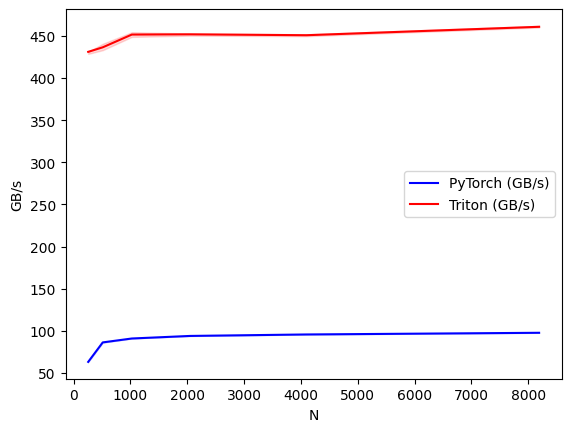

LayerNorm Forward Throughput:
        N  PyTorch (GB/s)  Triton (GB/s)
0   256.0       63.022961     431.157914
1   512.0       86.171343     436.542900
2  1024.0       90.813320     451.680360
3  2048.0       93.852248     451.972420
4  4096.0       95.603212     450.903482
5  8192.0       97.593306     460.912509


In [10]:
import triton.testing


def layernorm_forward_torch(x, weight, bias, eps=1e-5):
    mean = x.mean(dim=-1, keepdim=True)
    var  = x.var(dim=-1, unbiased=False, keepdim=True)
    rstd = 1.0 / torch.sqrt(var + eps)
    return (x - mean) * rstd * weight + bias


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],
        x_vals=[256, 512, 1024, 2048, 4096, 8192],
        line_arg='provider',
        line_vals=['torch', 'triton'],
        line_names=['PyTorch', 'Triton'],
        styles=[('blue', '-'), ('red', '-')],
        ylabel='GB/s',
        plot_name='LayerNorm Forward Throughput',
        args={'M': 4096},
    )
)
def benchmark(M, N, provider):
    x = torch.randn(M, N, device='cuda', dtype=torch.float32)
    w = torch.ones(N,  device='cuda', dtype=torch.float32)
    b = torch.zeros(N, device='cuda', dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]

    fn = (lambda: layernorm_forward_torch(x, w, b)) if provider == 'torch' else (lambda: layernorm_forward_triton(x, w, b))

    ms, min_ms, max_ms = triton.testing.do_bench(fn, quantiles=quantiles)
    gbps = lambda t: (4 * M * N * 4) / t * 1e-6
    return gbps(ms), gbps(max_ms), gbps(min_ms)


benchmark.run(show_plots=True, print_data=True)
